# Can this IMU detect a sprint start?

**Evaluating the Seeed XIAO nRF52840 Sense (LSM6DS3) for false-start detection and reaction-time measurement.**

---

The rule this system has to serve is simple. World Athletics treats any push-off occurring **less than 100 ms** after the gun as a false start, on the grounds that no human can hear, process and react faster than that. A device that wants to make that call has to answer one question with confidence:

> **At what instant did the athlete leave the blocks?**

Everything else — the audio sequence, the BLE link, the app — is scaffolding around that single timestamp. So this notebook asks two separate questions about the recording captured from the prototype, and it is important that they stay separate:

| | Question | What would fail it |
|---|---|---|
| **1. Sensitivity** | Can the sensor *see* a push-off at all, cleanly above its own noise? | A noise floor close to the signal |
| **2. Timing** | Can we say *when* it happened, precisely enough for a 100 ms rule? | Coarse or unreliable time resolution |

A sensor can pass the first and fail the second. As we will see, that is exactly what happens here — and the distinction decides how the firmware must be built.

## Setup

The recording is a 14-second capture streamed over BLE at a nominal 50 Hz from the live-data screen, exported as CSV. It contains a period of rest and three deliberate taps on the device.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# --- Validated categorical palette (slots 1-3) -----------------------------
AX = {"x_g": "#2a78d6", "y_g": "#eb6834", "z_g": "#1baf7a"}
LABEL = {"x_g": "X", "y_g": "Y", "z_g": "Z"}
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#8a8981"
SURFACE, ACCENT = "#fcfcfb", "#e34948"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.size": 10, "font.family": "sans-serif",
    "axes.edgecolor": "#dcdbd4", "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": INK3, "ytick.color": INK3,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "xtick.direction": "out", "ytick.direction": "out",
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#ebeae3", "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.dpi": 130,
})

df = pd.read_csv("prostart_imu_20260829_213017.csv")
df["mag_g"] = np.sqrt(df.x_g**2 + df.y_g**2 + df.z_g**2)
AXES = ["x_g", "y_g", "z_g"]

duration = df.elapsed_s.iloc[-1]
print(f"{len(df)} samples over {duration:.2f} s  ->  {(len(df)-1)/duration:.1f} Hz effective")
df.head()

700 samples over 14.31 s  ->  48.8 Hz effective


,timestamp_iso,elapsed_s,x_g,y_g,z_g,mag_g
0,2026-08-29T21:30:17.754527,0.000000,0.007198,-0.007198,0.991372,0.991424
1,2026-08-29T21:30:17.754637,0.000110,0.005124,-0.007686,0.990396,0.990439
2,2026-08-29T21:30:18.048163,0.293636,0.004880,-0.007808,0.990762,0.990805
3,2026-08-29T21:30:18.048397,0.293870,0.006100,-0.007442,0.990884,0.990931
4,2026-08-29T21:30:18.048509,0.293982,0.007320,-0.006954,0.990884,0.990935


### Orientation check

Before trusting any of it: at rest, gravity has to show up as **1 g on one axis and ~0 on the other two**. If the numbers were 4× off, the firmware's `accelRange` and the library's scaling would have diverged.

In [2]:
rest = df[df.elapsed_s < 2.5]
summary = pd.DataFrame({
    "mean (g)":  [rest[a].mean() for a in AXES],
    "std (mg)":  [rest[a].std() * 1e3 for a in AXES],
    "min (g)":   [df[a].min() for a in AXES],
    "max (g)":   [df[a].max() for a in AXES],
}, index=[LABEL[a] for a in AXES]).round(4)

print(f"Resting vector magnitude: {rest.mag_g.mean():.4f} g   (expected 1.0000)")
summary

Resting vector magnitude: 0.9907 g   (expected 1.0000)


,mean (g),std (mg),min (g),max (g)
X,0.0065,0.9176,-0.1543,0.1577
Y,-0.0072,0.7340,-0.2031,0.1337
Z,0.9907,0.3683,0.8136,1.1002


The board is lying flat: **Z carries gravity at 0.99 g**, X and Y sit within a few mg of zero, and the resting vector magnitude is 0.991 g — within 1% of the expected 1 g. The scaling is correct and the axes are sane. We can trust the numbers.

## 1 · The full recording

Three events, nothing else. The rest of the trace is the device sitting still.

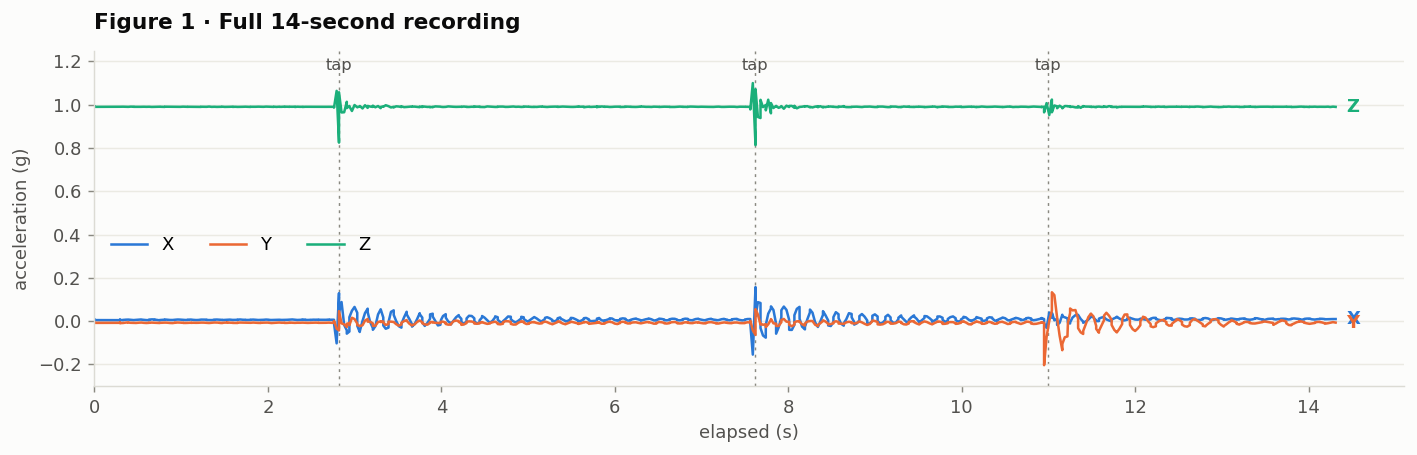

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.6))
for a in AXES:
    ax.plot(df.elapsed_s, df[a], color=AX[a], lw=1.4, label=LABEL[a])
    ax.annotate(LABEL[a], (df.elapsed_s.iloc[-1], df[a].iloc[-1]),
                xytext=(6, 0), textcoords="offset points",
                color=AX[a], fontsize=10, fontweight="600", va="center")

for t in (2.82, 7.62, 11.00):
    ax.axvline(t, color=INK3, lw=0.8, ls=(0, (2, 3)), zorder=0)
    ax.annotate("tap", (t, 1.16), ha="center", color=INK2, fontsize=9)

ax.set(xlabel="elapsed (s)", ylabel="acceleration (g)",
       title="Figure 1 · Full 14-second recording", xlim=(0, 15.1), ylim=(-0.3, 1.25))
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(loc="center left", ncol=3, bbox_to_anchor=(0, 0.42))
plt.tight_layout(); plt.show()

At this scale the three taps barely register — they look like minor wobbles on a flat line. That flatness is the first genuinely good news, and it is worth zooming in far enough to see just *how* flat it is.

## 2 · Sensitivity — how quiet is the sensor at rest?

This is the measurement that decides whether the sensor is usable. **Rescaled from ±1 g to ±3 mg**, a 300× magnification, we are now looking at the sensor's own noise with gravity subtracted out.

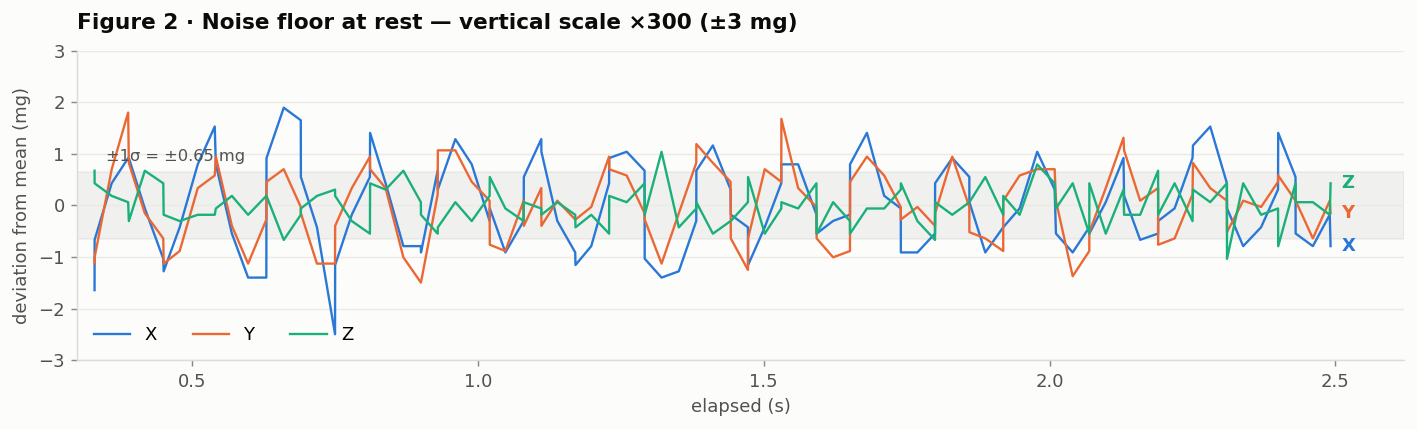

In [4]:
seg = df[(df.elapsed_s > 0.3) & (df.elapsed_s < 2.5)]
fig, ax = plt.subplots(figsize=(11, 3.4))

for a in AXES:
    d = (seg[a] - seg[a].mean()) * 1e3          # mg, mean-removed
    ax.plot(seg.elapsed_s, d, color=AX[a], lw=1.3, label=LABEL[a])
    ax.annotate(LABEL[a], (seg.elapsed_s.iloc[-1], d.iloc[-1]),
                xytext=(6, 0), textcoords="offset points",
                color=AX[a], fontsize=10, fontweight="600", va="center")

band = seg[AXES].std().mean() * 1e3
ax.axhspan(-band, band, color=INK3, alpha=0.10, zorder=0)
ax.annotate(f"±1σ = ±{band:.2f} mg", (0.35, band), xytext=(0, 6),
            textcoords="offset points", color=INK2, fontsize=9)

ax.set(xlabel="elapsed (s)", ylabel="deviation from mean (mg)",
       title="Figure 2 · Noise floor at rest — vertical scale ×300 (±3 mg)",
       xlim=(0.3, 2.62), ylim=(-3, 3))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(loc="lower left", ncol=3)
plt.tight_layout(); plt.show()

In [5]:
rest_mean = df[AXES].iloc[:50].mean()
df["dev_g"] = df[AXES].sub(rest_mean).abs().max(axis=1)   # worst-axis deviation
df["mag_dev_g"] = (df.mag_g - 1).abs()                    # deviation of |a| from 1 g

noise = seg[AXES].std().mean()
peak  = df.dev_g.max()

print(f"Noise floor (1σ, averaged over axes) : {noise*1e3:6.2f} mg")
print(f"Largest tap deviation (worst axis)   : {peak*1e3:6.1f} mg")
print(f"Signal-to-noise ratio                : {peak/noise:6.0f}×   ({20*np.log10(peak/noise):.0f} dB)")

Noise floor (1σ, averaged over axes) :   0.65 mg
Largest tap deviation (worst axis)   :  195.9 mg
Signal-to-noise ratio                :    300×   (50 dB)


**The sensor is extremely quiet.** The noise floor is under 1 mg — that is 0.001 g, roughly a thousandth of gravity. Even the light finger taps in this recording, which are nowhere near a sprinter's push-off, tower over it at **~300×** the noise.

For context on how much margin that leaves: a real push-off from starting blocks produces on the order of **1–3 g** of acceleration on the device body. Against a 0.7 mg noise floor, that is a signal-to-noise ratio in the range of **1500–4600×**. A detection threshold could sit at 20 mg — nearly 30σ above the noise, immune to false triggering from a footstep or a gust — and still be crossed by a genuine start with a factor of 50 or more to spare.

> **Question 1 is settled: sensitivity is not a constraint.** Detecting *that* a push-off happened is close to trivial for this sensor.

## 3 · The events, close up

So the peaks are unmistakable. But detection was never the hard part — the hard part is *timing*. Here are both taps at full resolution, with the moment of onset marked. Each dot is one real sample.

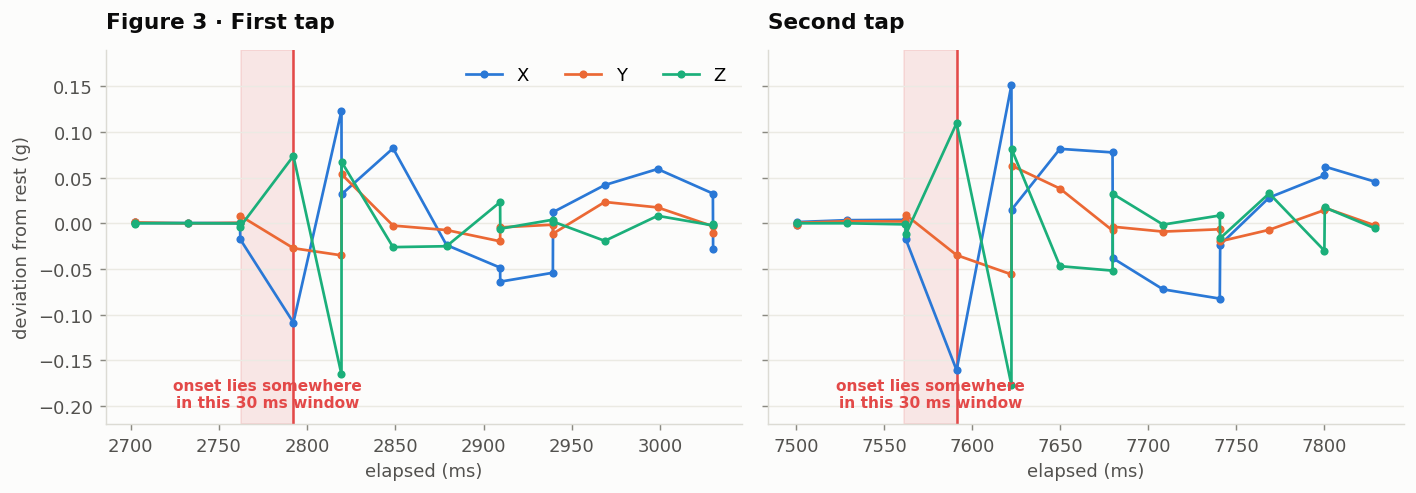

In [6]:
THRESH = 0.020                      # 20 mg - the detection threshold proposed below
GAP    = np.median(np.diff(df.elapsed_s)[np.diff(df.elapsed_s) > 1e-3]) * 1e3

events = [(2.70, 3.05, "Figure 3 · First tap"), (7.50, 7.85, "Second tap")]
fig, axes_ = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
rest_mean = df[AXES].iloc[:50].mean()

for ax, (t0, t1, name) in zip(axes_, events):
    e = df[(df.elapsed_s >= t0) & (df.elapsed_s <= t1)]
    dev = e[AXES].sub(rest_mean).abs().max(axis=1)
    t_cross = e.elapsed_s[dev > THRESH].iloc[0] * 1e3

    # The onset lies somewhere in the interval preceding the first crossing -
    # one real BLE delivery gap wide, because that is how coarsely arrival
    # timestamps can place it.
    ax.axvspan(t_cross - GAP, t_cross, color=ACCENT, alpha=0.12, zorder=0)
    ax.axvline(t_cross, color=ACCENT, lw=1.4)

    for a in AXES:
        ax.plot(e.elapsed_s * 1e3, e[a] - rest_mean[a],
                color=AX[a], lw=1.5, marker="o", ms=3.5, label=LABEL[a])

    ax.annotate(f"onset lies somewhere\nin this {GAP:.0f} ms window",
                (t_cross - GAP / 2, -0.205), ha="center", va="bottom",
                color=ACCENT, fontsize=8.5, fontweight="600")
    ax.set(xlabel="elapsed (ms)", title=name, ylim=(-0.22, 0.19))
    ax.yaxis.grid(True); ax.set_axisbelow(True)

axes_[0].set_ylabel("deviation from rest (g)")
axes_[0].legend(loc="upper right", ncol=3)
plt.tight_layout(); plt.show()

Look at the red band. The trace goes from flat to a full-amplitude peak in **a single sample step**. The event itself is sharp — sharper than the sensor is reporting it — but the recording cannot place its start any more precisely than "somewhere in this ~30 ms window."

That is a problem, and it has nothing to do with the sensor. We come back to it in section 4.

### The third event — and why the obvious detector is the wrong one

The tap at 11.0 s deserves its own look, because it nearly escaped this analysis. The first pass at finding events thresholded on the **vector magnitude** |a| = √(x²+y²+z²) — the intuitive choice, since it is orientation-independent and needs no calibration. That pass found the taps at 2.8 s and 7.6 s and missed the third one entirely.

The reason is geometric. The device rests with gravity on Z, so |a| ≈ 1 g. A *horizontal* acceleration adds to that in quadrature rather than linearly:

$$|a| = \sqrt{(1\,\text{g})^2 + a_h^2} \approx 1\,\text{g} + \frac{a_h^2}{2}$$

For small horizontal accelerations the quadratic term is tiny, so |a| barely moves. The third tap was almost purely lateral — and the magnitude detector nearly slept through it.

In [7]:
e3 = df[(df.elapsed_s > 10.90) & (df.elapsed_s < 11.45)]
per_axis = e3[AXES].sub(rest_mean).abs().max()

print("Third event (~10.95 s), peak deviation:")
for a in AXES:
    print(f"   {LABEL[a]} axis          : {per_axis[a]*1e3:6.1f} mg")
print(f"   vector magnitude : {e3.mag_dev_g.max()*1e3:6.1f} mg")
print(f"\n   -> magnitude under-reports this event by {per_axis.max()/e3.mag_dev_g.max():.1f}×")

Third event (~10.95 s), peak deviation:
   X axis          :   37.3 mg
   Y axis          :  195.9 mg
   Z axis          :   38.0 mg
   vector magnitude :   46.5 mg

   -> magnitude under-reports this event by 4.2×


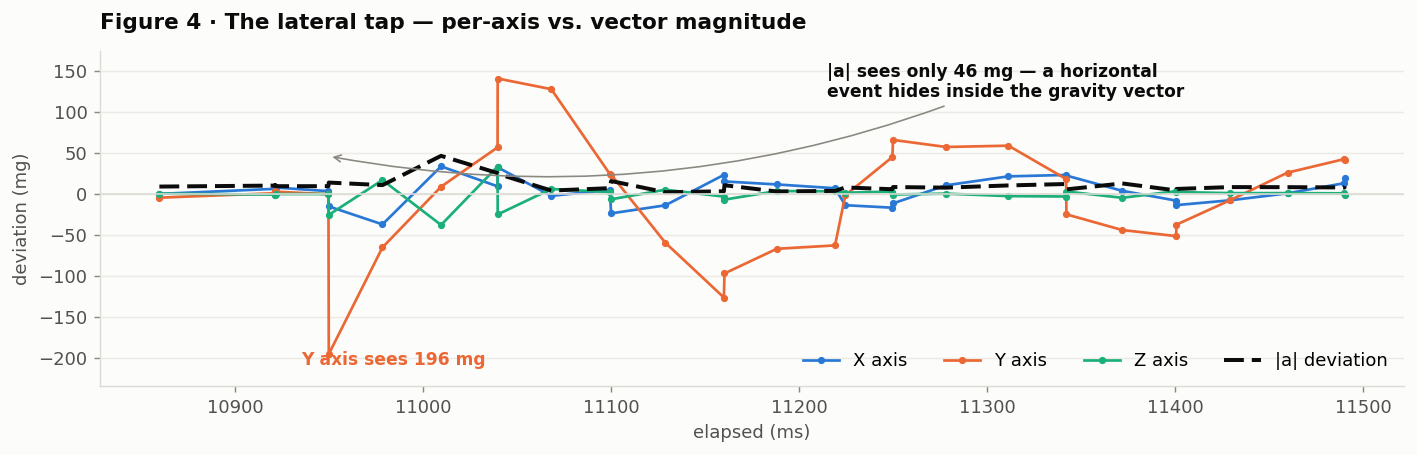

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.6))
w = df[(df.elapsed_s > 10.85) & (df.elapsed_s < 11.5)]
t = w.elapsed_s * 1e3

for a in AXES:
    ax.plot(t, (w[a] - rest_mean[a]) * 1e3, color=AX[a], lw=1.5,
            marker="o", ms=3, label=f"{LABEL[a]} axis")
ax.plot(t, w.mag_dev_g * 1e3, color=INK, lw=2.2, ls=(0, (5, 2)),
        label="|a| deviation")

ax.axhline(0, color="#dcdbd4", lw=0.9)
ax.annotate("Y axis sees 196 mg", (t.iloc[3], -196), xytext=(14, -6),
            textcoords="offset points", color=AX["y_g"], fontsize=9.5, fontweight="600")
ax.annotate("|a| sees only 46 mg — a horizontal\nevent hides inside the gravity vector",
            xy=(t.iloc[5], 46), xycoords="data",
            xytext=(11215, 118), textcoords="data",
            color=INK, fontsize=9.5, fontweight="600",
            arrowprops=dict(arrowstyle="->", color=INK3, lw=0.9,
                            connectionstyle="arc3,rad=-0.15"))
ax.set_ylim(-235, 175)

ax.set(xlabel="elapsed (ms)", ylabel="deviation (mg)",
       title="Figure 4 · The lateral tap — per-axis vs. vector magnitude")
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(loc="lower right", ncol=4)
plt.tight_layout(); plt.show()

> **Do not threshold on |a|.** For this event the magnitude detector is **4.2× less sensitive** than watching the axes directly. That matters more than it might appear: the athlete drives *backward against the blocks*, so the impulse on the block body is predominantly horizontal and along the track axis — precisely the direction |a| suppresses. A threshold tuned on |a| with vertical bench taps would be badly miscalibrated for the real motion.

**The better detector is the horizontal-plane magnitude**, `sqrt(Δx² + Δy²)`, with Z vertical and Δ taken against a resting baseline. Gravity lives entirely on Z, so it never enters the sum — which is exactly what went wrong with |a|:

| Detector | Vertical taps | Lateral tap |
|---|---|---|
| Vector magnitude \|a\| | 164–169 mg | **46 mg** |
| Worst single axis | 128–165 mg | 196 mg |
| **Horizontal plane** √(Δx²+Δy²) | 128–165 mg | **196 mg** |

It keeps full sensitivity in both cases on a ~1 mg noise floor, and it is orientation-independent within the mounting plane — so it does not depend on getting the device's yaw right when strapping it to the block.

This does not weaken the sensitivity conclusion: even the suppressed 46 mg is 70σ above the noise. But it determines how the firmware should compute its trigger.

## 4 · Timing — where the prototype actually fails

The onset windows in Figure 3 were 30 ms wide, which is already a warning. Looking at the arrival times directly makes the cause plain: if samples arrived on a clean 50 Hz cadence, consecutive timestamps would differ by 20 ms every time. They do not.

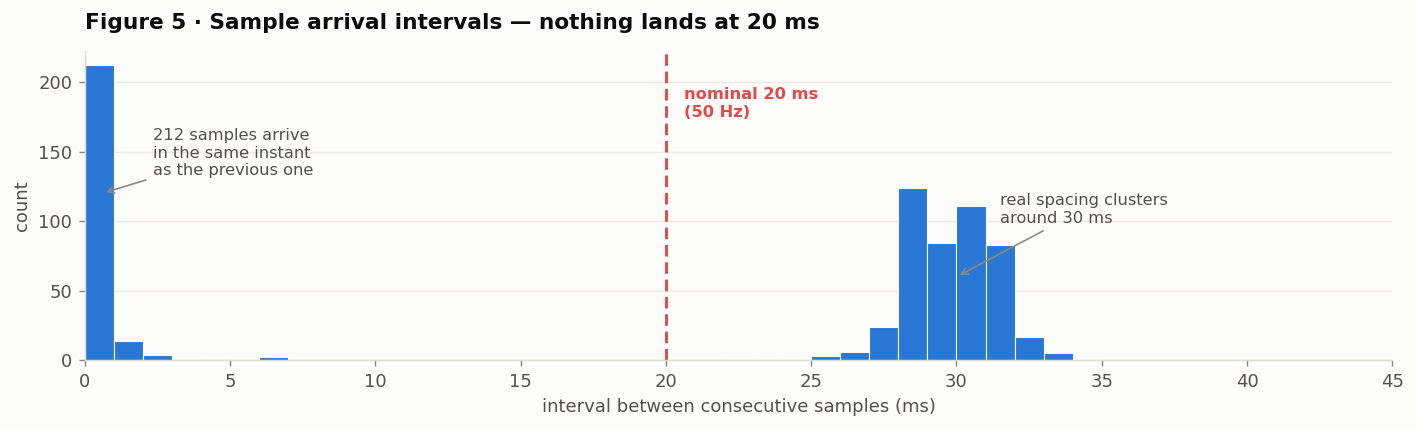

In [9]:
dt = np.diff(df.elapsed_s) * 1e3

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(dt, bins=np.arange(0, 46, 1), color="#2a78d6", edgecolor=SURFACE, linewidth=0.6)

ax.axvline(20, color=ACCENT, lw=1.6, ls=(0, (4, 2)))
ax.annotate("nominal 20 ms\n(50 Hz)", (20, 175), xytext=(10, 0),
            textcoords="offset points", color=ACCENT, fontsize=9, fontweight="600")
ax.annotate(f"{(dt < 1).sum()} samples arrive\nin the same instant\nas the previous one",
            (0.6, 120), xytext=(28, 10), textcoords="offset points",
            color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=INK3, lw=0.9))
ax.annotate("real spacing clusters\naround 30 ms", (30, 60), xytext=(24, 30),
            textcoords="offset points", color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=INK3, lw=0.9))

ax.set(xlabel="interval between consecutive samples (ms)", ylabel="count",
       title="Figure 5 · Sample arrival intervals — nothing lands at 20 ms", xlim=(0, 45))
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

In [10]:
paired = (dt < 1).sum()
print(f"Intervals under 1 ms (batched arrivals) : {paired:3d} of {len(dt)}  ({paired/len(dt):.0%})")
print(f"Median of the remaining intervals       : {np.median(dt[dt >= 1]):.1f} ms")
print(f"Worst-case gap                          : {dt.max():.0f} ms")

Intervals under 1 ms (batched arrivals) : 212 of 699  (30%)
Median of the remaining intervals       : 29.7 ms
Worst-case gap                          : 294 ms


The distribution is bimodal, and **the nominal 20 ms bin is empty**. Roughly a third of samples arrive with *no measurable gap at all* from the previous one, and the rest are spaced around 30 ms.

This is BLE connection-event batching. The firmware genuinely produces samples every 20 ms, but the radio delivers them in bursts of one or two whenever a connection event comes around — the app requested a 15–30 ms interval and the phone granted ~30 ms. The app then timestamps each sample **on arrival**, so two readings taken 20 ms apart on the device get written to the CSV with nearly identical timestamps.

> **The timestamps in this file do not describe when the sensor was read.** They describe when the phone happened to receive the packet. The error is not noise around a correct value — it is a systematic ±30 ms distortion.

### What ±30 ms means against a 100 ms rule

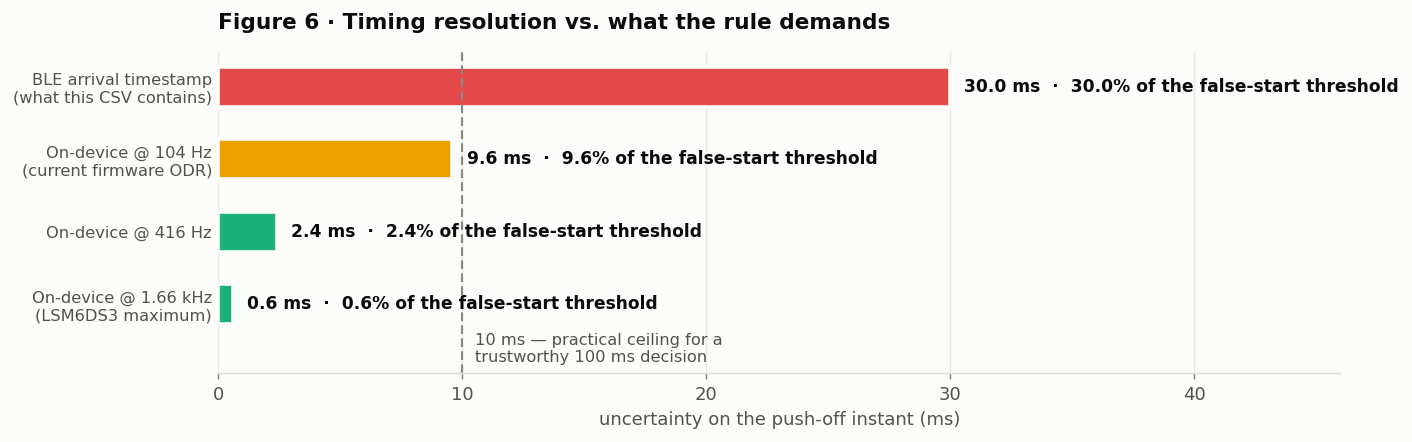

In [11]:
options = [
    ("BLE arrival timestamp\n(what this CSV contains)", 30.0,   "#e34948"),
    ("On-device @ 104 Hz\n(current firmware ODR)",       9.6,   "#eda100"),
    ("On-device @ 416 Hz",                               2.4,   "#1baf7a"),
    ("On-device @ 1.66 kHz\n(LSM6DS3 maximum)",          0.6,   "#1baf7a"),
]
fig, ax = plt.subplots(figsize=(11, 3.5))
ypos = np.arange(len(options))[::-1]

for y, (name, val, col) in zip(ypos, options):
    ax.barh(y, val, height=0.55, color=col, edgecolor=SURFACE, linewidth=2)
    ax.annotate(f"{val} ms  ·  {val/100:.1%} of the false-start threshold",
                (val, y), xytext=(8, 0), textcoords="offset points",
                va="center", color=INK, fontsize=9.5, fontweight="600")

ax.axvline(10, color=INK3, lw=1.2, ls=(0, (4, 2)))
ax.annotate("10 ms — practical ceiling for a\ntrustworthy 100 ms decision", (10, -0.62),
            xytext=(7, 0), textcoords="offset points", color=INK2, fontsize=9, va="center")

ax.set_yticks(ypos, [o[0] for o in options], fontsize=9)
ax.set(ylim=(-0.95, 3.5))
ax.set(xlabel="uncertainty on the push-off instant (ms)", xlim=(0, 46),
       title="Figure 6 · Timing resolution vs. what the rule demands")
ax.xaxis.grid(True); ax.set_axisbelow(True)
ax.spines["left"].set_visible(False); ax.tick_params(axis="y", length=0)
plt.tight_layout(); plt.show()

The BLE-arrival number is disqualifying on its own: a 30 ms uncertainty is **30% of the entire quantity being measured**. A reaction time reported as 105 ms could be anywhere from 75 ms to 135 ms — the difference between a clean start and a disqualification.

Note the second row too. Even reading the IMU on-device at the **current** firmware setting of 104 Hz leaves 9.6 ms of quantization, right at the edge of acceptable. That is a firmware constant worth changing.

---

## Verdict

**Yes — the LSM6DS3 is the right sensor. No — the current data path cannot measure reaction time.**

These are compatible statements, and separating them is the useful outcome of this analysis:

| | Finding | Verdict |
|---|---|---|
| **Noise floor** | 0.7 mg (1σ) | Excellent — 3 orders of magnitude below a real push-off |
| **Peak detection** | ~300× SNR on light taps; 1500×+ expected on a start | Trivially detectable |
| **Axis scaling** | 0.991 g at rest | Correct |
| **Detector choice** | \|a\| under-reports a lateral event 4.2× | Threshold on horizontal-plane magnitude |
| **Sample cadence** | Bimodal, batched, 20 ms bin empty | Transport artefact |
| **Timing precision** | ±30 ms via BLE arrival | **Unusable for a 100 ms rule** |

### What follows for the design

1. **Never derive reaction time from the BLE stream.** The live-data feed is a visualization tool and nothing more. This was already the intended architecture — the single-shot `micros()` "go" characteristic exists precisely because of this — and the data confirms that split was the right call rather than a premature optimization.
2. **Detect the push-off on the device**, in the firmware loop, and timestamp it with `micros()` against the same clock that emitted the start tone. Transmit the resulting *number*, not the waveform. Latency of the radio then becomes irrelevant: a packet that arrives 200 ms late still carries a microsecond-accurate timestamp.
3. **Raise the accelerometer ODR for the detection path.** The current `accelSampleRate = 104` was chosen to comfortably feed a 50 Hz visualization stream, and for that purpose it is fine. For detection it is the limiting factor — **416 Hz or 833 Hz** brings quantization to 2.4 / 1.2 ms, safely under the 10 ms ceiling, at negligible cost since the gyroscope is already disabled.
4. **Trigger on the horizontal-plane magnitude `sqrt(Δx² + Δy²)`, never on |a|.** Section 3 showed |a| suppressing a lateral event by 4.2×, and the drive out of the blocks is mostly horizontal. Excluding the vertical axis keeps gravity out of the sum while staying orientation-independent in the mounting plane.
5. **A fixed threshold is viable.** Given the measured noise floor, a trigger at ~20 mg sits ~30σ clear of the noise while a genuine start exceeds it by 50×. No adaptive filtering or complex onset algorithm is needed for a first working version.

### What this recording cannot tell us

Honesty about scope: the three events here are **finger taps on a benchtop**, not an athlete driving out of starting blocks. They establish the noise floor, expose the timing problem, and reveal the magnitude-detector trap — all three are properties of the hardware and the data path, and all three transfer. They do **not** validate the detection threshold against real start dynamics, tell us how the device behaves when strapped to a block, or reveal whether an athlete's pre-start fidgeting produces false triggers.

The next measurement worth taking is a recording at 416 Hz+ logged **on-device**, from a device mounted where it will actually live.